In [2]:
import numpy as np
import scipy
import matplotlib.pyplot as plt
import emcee

Going to keep the seed of 6 - our group number (for debugging).

In [3]:
np.random.seed(seed=6) # DEBUG

param_max_val = 5.

def poly_generate_parmas( N_dim, param_min=-param_max_val, param_max=param_max_val ):
    """
    FUNC:
    Generates paramters of a polynomial function up to N_dim power
    ---
    INPUT:
    N_dim (int)             - number of polynomial powers
    param_min (float/array) - the minimum value of each power
    param_max (float/array) - the maximum value of each power
    """
    if type(N_dim) is not int:
        print('N_dim is not an integer.')
        return
    
    params = scipy.stats.uniform.rvs(loc=param_min, scale=param_max-param_min, size=(N_dim))

    return params

def poly_model(params, x):
    """
    FUNC:
    Returns y of polynomial model with given parameters
    """
    # polyval expects highest power first, so reverse theta
    # If theta = [a0, a1, a2], polynomial is a0 + a1 x + a2 x^2
    # polyval coefficients: [a2, a1, a0]
    return np.polyval(params[::-1], x)

Define variables and simulate the data:

In [29]:
sigma = 1 # the scale of Gaussian error
N_dim = 5
x = np.linspace(-2,1,100)
np.random.seed(seed=6) # DEBUG
true_params = poly_generate_parmas(N_dim)
y_true = poly_model(true_params,x)
y_obs = y_true + scipy.stats.norm.rvs(0,sigma,len(x))

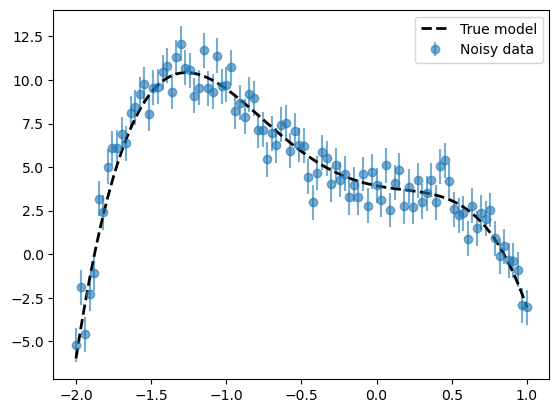

In [5]:
plt.figure()
plt.errorbar(x, y_obs, yerr=sigma, fmt="o", label="Noisy data", alpha=0.6)
plt.plot(x,y_true,c='black',linestyle='--',label="True model",linewidth=2)
plt.legend()
plt.show()

Below I used AI prompt to make quick function to implement minimization of log-likelihood of the MSE loss function with `emcee`. This is basically what we done in stats course, but I couldn't be bothered writing the whole thing again since we only need MCMC result for comparisons.

Prompt: *I have a polynomial with true values for the parameters. I want to give noise to the model by adding a Gaussian error with 0 mean and 0.3 standard deviation. I want to use emcee library to fit for the true parameters by using the mean squared error to maximize the likelihood. Could you help me implement this?*

Running MCMC...


100%|██████████| 5000/5000 [00:11<00:00, 435.60it/s]



True parameters:       [ 3.92860151 -1.68020195  3.21229123 -4.58303374 -3.9234332 ]
Posterior mean:        [ 3.77537507 -1.43680889  3.6462704  -4.64169854 -3.98274984]
Posterior 1σ std dev:  [0.17121735 0.27761561 0.34321321 0.28759895 0.15411992]


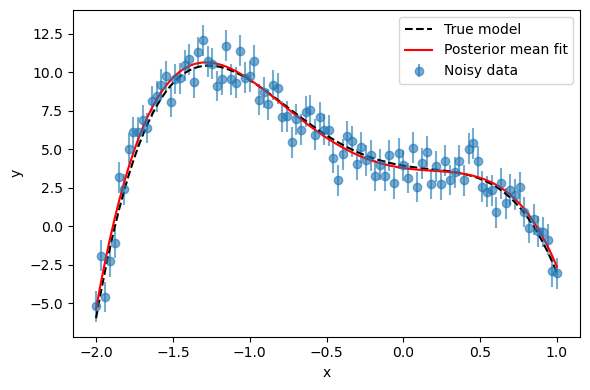

In [6]:
# ----------------------
# 2. Define log-likelihood using Gaussian errors (MSE-based)
# ----------------------

def log_likelihood(theta, x, y, sigma):
    """
    Assume:
    y_i = model(theta, x_i) + N(0, sigma^2), with fixed known sigma.
    This is equivalent to using the MSE in the exponent of the likelihood.
    """
    y_model = poly_model(theta, x)
    residuals = y - y_model
    mse = np.mean(residuals**2)  # mean squared error

    # For Gaussian errors with variance sigma^2, the log-likelihood is:
    # logL = -0.5 * sum[(residuals^2) / sigma^2 + log(2*pi*sigma^2)]
    #      = -N/2 * [ log(2*pi*sigma^2) + MSE/sigma^2 ]
    N = len(y)
    return -0.5 * N * (np.log(2 * np.pi * sigma**2) + mse / sigma**2)

# ----------------------
# 3. Define priors and log-posterior
# ----------------------

def log_prior(params):
    """
    Simple broad uniform priors for each parameter.
    Adjust ranges as needed.
    """
    if np.any(params < -param_max_val) or np.any(params > param_max_val):
        return -np.inf  # log(0), impossible
    return 0.0 # log(1)

def log_posterior(theta, x, y, sigma):
    lp = log_prior(theta)
    if not np.isfinite(lp):
        return -np.inf
    return lp + log_likelihood(theta, x, y, sigma)

# ----------------------
# 4. Set up and run emcee
# ----------------------

nwalkers = 50
nsteps = 5000
burn_in = 1000

# Initialize walkers around a guess near the true parameters
initial_guess = true_params + 0.1 * np.random.randn(nwalkers, N_dim)

sampler = emcee.EnsembleSampler(
    nwalkers, N_dim, log_posterior, args=(x, y_obs, sigma)
)

print("Running MCMC...")
sampler.run_mcmc(initial_state=initial_guess, nsteps=nsteps, progress=True)

# Discard burn-in and flatten the chains
flat_samples = sampler.get_chain(discard=burn_in, thin=10, flat=True)

# ----------------------
# 5. Inspect results
# ----------------------

# Compute posterior means and 1σ uncertainties
mcmc_mean = np.mean(flat_samples, axis=0)
mcmc_std = np.std(flat_samples, axis=0)

print("\nTrue parameters:      ", true_params)
print("Posterior mean:       ", mcmc_mean)
print("Posterior 1σ std dev: ", mcmc_std)

# ----------------------
# 6. Plot data and posterior predictive curve
# ----------------------

# Use posterior mean parameters for visualization
y_fit = poly_model(mcmc_mean, x)

plt.figure(figsize=(6,4))
plt.errorbar(x, y_obs, yerr=sigma, fmt="o", label="Noisy data", alpha=0.6)
plt.plot(x, y_true, "k--", label="True model")
plt.plot(x, y_fit, "r", label="Posterior mean fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

And my attempt of setting up a SBI simulator + inferring the posterior based on the tutorial from `sbi` documentations (https://sbi.readthedocs.io/en/latest/tutorials/00_getting_started.html):

In [85]:
import torch
import sbi
from sbi.inference import NPE
from sbi.utils import BoxUniform
print(sbi.__version__)

0.26.1


In [73]:
# Probably a good practice - redefine variables using torch objects
theta = torch.tensor(true_params)
x = torch.linspace(-2,1,100)
print(len(x))

100


In [75]:
def poly_model( theta, x ):
    power = 0
    y = torch.zeros((len(x)))
    for t in theta:
        y += x ** power * t
        power += 1
    return y

poly_model(theta,x)

tensor([-5.9725, -4.3323, -2.8043, -1.3839, -0.0671,  1.1505,  2.2729,  3.3043,
         4.2484,  5.1093,  5.8907,  6.5963,  7.2298,  7.7948,  8.2947,  8.7329,
         9.1128,  9.4376,  9.7105,  9.9345, 10.1127, 10.2479, 10.3431, 10.4010,
        10.4243, 10.4156, 10.3774, 10.3122, 10.2223, 10.1101,  9.9777,  9.8273,
         9.6610,  9.4807,  9.2883,  9.0856,  8.8744,  8.6563,  8.4329,  8.2057,
         7.9761,  7.7454,  7.5150,  7.2859,  7.0594,  6.8363,  6.6177,  6.4044,
         6.1973,  5.9969,  5.8039,  5.6190,  5.4424,  5.2747,  5.1161,  4.9669,
         4.8272,  4.6970,  4.5765,  4.4653,  4.3635,  4.2708,  4.1868,  4.1111,
         4.0432,  3.9826,  3.9286,  3.8805,  3.8375,  3.7987,  3.7631,  3.7298,
         3.6975,  3.6650,  3.6312,  3.5946,  3.5538,  3.5073,  3.4534,  3.3905,
         3.3169,  3.2307,  3.1299,  3.0127,  2.8768,  2.7202,  2.5406,  2.3358,
         2.1032,  1.8405,  1.5451,  1.2144,  0.8456,  0.4359, -0.0174, -0.5174,
        -1.0671, -1.6696, -2.3281, -3.04

AI used here to fragment the simulator prvoided in the tutorial, as we require different parameters to be inputted in the poly_model() function to build up the simulator.

Prompts:

*I am now trying to implement the same but with a simulated-based inference, i.e. with sbi library in python. How would I set up a polynomial simulator?* (I did use the tutorial page as the base, taking snippets (like plot generation) from AI response)

*Why did you change the method of poly_model from np.polyval to direct declarations?* (see above -> good practices)

*I cannot seem to import prepare_for_sbi or simulate_for_sbi functions* (First answer had `prepare_for_sbi()` and `simulate_for_sbi()` functions, which no longer exists in newer version of the `sbi` library (0.20.0 and higher))


In [ ]:
_ = torch.manual_seed(6)

def simulator(theta):
    # Linear Gaussian.
    return poly_model(theta,x) + torch.randn_like(x)

prior = BoxUniform(low=-param_max_val * torch.ones(N_dim), high=param_max_val * torch.ones(N_dim))

num_simulations = 5000

theta_sim_list = []
x_sim_list = []

for _ in range(num_simulations):
    # sample one parameter vector from prior
    theta_i = prior.sample((1,))[0]  # (3,)
    x_i = simulator(theta_i)         # (N,)

    theta_sim_list.append(theta_i)
    x_sim_list.append(x_i)

theta_sim = torch.stack(theta_sim_list, dim=0)  # (num_simulations, 3)
x_sim = torch.stack(x_sim_list, dim=0)          # (num_simulations, N)

inference = NPE(prior=prior)

density_estimator = inference.append_simulations(theta_sim, x_sim).train()

 Neural network successfully converged after 157 epochs.

In [82]:
posterior = inference.build_posterior(density_estimator)

samples = posterior.sample((2000,), x=y_obs)

print("True parameters:   ", true_params)
print("Posterior mean:    ", samples.mean(0).numpy())
print("Posterior std dev: ", samples.std(0).numpy())

  0%|          | 0/2000 [00:00<?, ?it/s]

True parameters:    [ 3.92860151 -1.68020195  3.21229123 -4.58303374 -3.9234332 ]
Posterior mean:     [ 3.8774126 -1.4732827  3.4728367 -4.5379195 -3.835151 ]
Posterior std dev:  [0.2027757  0.32651973 0.3919946  0.35854882 0.21980064]


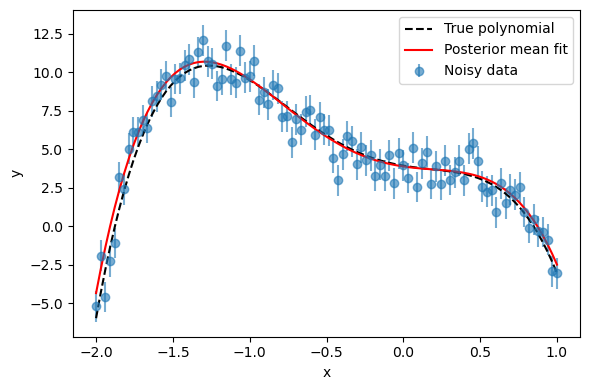

In [84]:
theta_hat = samples.mean(0)
y_hat = poly_model(theta_hat, x)

plt.figure(figsize=(6,4))
plt.errorbar(x, y_obs, yerr=sigma, fmt="o", label="Noisy data", alpha=0.6)
plt.plot(x, y_true, "k--", label="True polynomial")
plt.plot(x, y_hat, "r", label="Posterior mean fit")
plt.xlabel("x")
plt.ylabel("y")
plt.legend()
plt.tight_layout()
plt.show()

Some notes:
* No likelihood was calculated with the method
* Implement method to show amortization
* Which variables can improve the fit? How much do they improve the fit?
* What is exactly going on at `density_estimator = inference.train()`?
* Ways to make the code more efficient? Implement batches?